In [1]:
# @title Imports
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import seaborn as sns
import matplotlib.pyplot as plt



from popy.simulation_tools import *
from popy.io_tools import load_behavior
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *

from popy.config import COLORS, PROJECT_PATH_LOCAL

In [2]:
def load_res():
    # show bic and LPT values
    
    # load behavior data
    floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'model_optimizing', f'optimization_results_po.csv')
    res_temp = pd.read_csv(floc)

    # simulations
    sim_floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'model_optimizing', f'simulation_behaviors_po.pkl')
    sim_data = pd.read_pickle(sim_floc)
    sim_data['best_arm'] = sim_data['action'] == sim_data['best_arm']
    for model in res_temp['Model'].unique():
        prop_best_target = sim_data.loc[sim_data['model'] == model, 'best_arm'].mean()
        res_temp.loc[res_temp['Model'] == model, 'prop_best_target'] = prop_best_target

    # change prob best arm in wsls agent to .99
    res_temp.loc[res_temp['Model'] == 'WSLS agent', 'prop_best_target'] = .77

    return res_temp

res_all = load_res()
#res_all = res_all.sort_values(['Model', 'monkey'])

res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickiness_bias,abandoned_bias,abandoned_decay,mean_reward_rate,prop_best_target
0,WSLS agent,0.010014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.55952,0.77000
1,Standard RL,NaN,0.772216,NaN,33.114164,NaN,NaN,NaN,NaN,NaN,NaN,0.55441,0.73146
2,Standard RL - stickiness,NaN,0.787848,NaN,39.003853,NaN,NaN,NaN,0.000000,NaN,NaN,0.55502,0.72663
3,Standard RL - forgetting,NaN,0.290279,NaN,66.429717,NaN,0.329674,0.314442,NaN,NaN,NaN,0.58806,0.80061
4,Standard RL - forgetting + stickiness,NaN,0.482944,NaN,83.618019,NaN,0.614430,0.225465,4.267171,NaN,NaN,0.58359,0.79536
5,Inferential RL,NaN,0.125982,NaN,77.118470,NaN,NaN,NaN,NaN,NaN,NaN,0.58649,0.80311
6,Inferential RL - stickiness,NaN,0.163601,NaN,90.508637,NaN,NaN,NaN,14.276535,NaN,NaN,0.58842,0.81111
7,Inferential RL - stickiness + multiple alphas,NaN,0.049277,0.212388,70.104930,NaN,NaN,NaN,0.000000,NaN,NaN,0.58698,0.81641
8,Foraging - no reset,NaN,0.387673,NaN,100.000000,0.226528,NaN,NaN,NaN,NaN,NaN,0.58087,0.78952
9,Foraging,NaN,0.278686,NaN,93.249073,0.312619,NaN,NaN,NaN,NaN,NaN,0.58184,0.79931


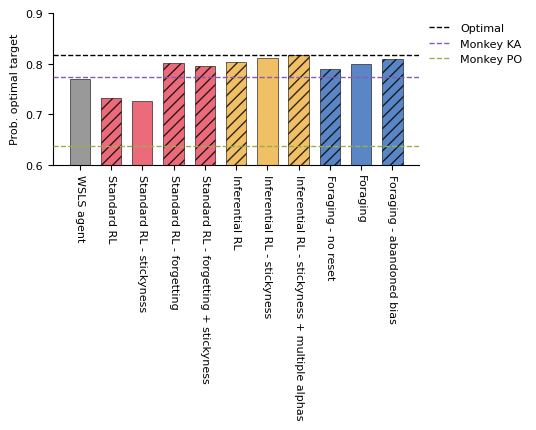

In [ ]:
def plot_res(res_all, paper_format=False):
    # Set font size and figure size
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        w, h = 4, 4
    else:
        plt.rcParams.update({'font.size': 8})
        w, h = 12, 5

    # Define the modes and figure
    modes = ['prop_best_target']
    fig, ax = plt.subplots(1, 1, figsize=(w/2.54, h/2.54), gridspec_kw={'wspace': 0})

    # Iterate over the modes and plot
    for i, mode in enumerate(modes):        
        # Get unique values
        models = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'Model'].unique()
        monkeys = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'monkey'].unique()

        # Set up positions
        x = np.arange(len(models))
        width = 0.5  # Width of bars
        offset = 0.25  # How much to offset for overlap

        for i, monkey in enumerate(monkeys):
            data = res_all.loc[(res_all['monkey'] == monkey) & (res_all['monkey'] != 'yu_DCZ')]
            values = [data.loc[data['Model'] == model, mode].iloc[0] if len(data.loc[data['Model'] == model]) > 0 else 0 for model in models]
            
            ax.bar(x + i*offset, values, width, 
                label=monkey, color=COLORS[monkey], 
                edgecolor='black', linewidth=0.5, alpha=0.8)
            
            for model, value in zip(models, values):
                print(f"{mode}: {monkey} {model}: {value:.2f}")

        # Configure axes
        ax.set_ylabel(mode)
        ax.set_xticks(x + offset/2)
        ax.set_xticklabels(models, rotation=45, horizontalalignment='right')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        #ax.legend()
        
        # Set y-axis limits and labels based on the mode
        ax.set_ylim(0.33, 0.80)
        ax.set_yticks(np.arange(0.4, 0.9, 0.1))
        ax.set_ylabel('LPT', fontsize=8)
        #ax.legend(title='Monkey', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1), frameon=True)

    return fig, ax

def plot_res(res_all, paper_format=False):
    # Set font size and figure size
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        w, h = 4, 4
    else:
        plt.rcParams.update({'font.size': 8})
        w, h = 12, 5

    # Define the modes and figure
    modes = ['prop_best_target']
    fig, ax = plt.subplots(1, 1, figsize=(w/2.54, h/2.54))

    # Get unique values
    models = res_all['Model'].unique()
    #monkeys = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'monkey'].unique()

    # Iterate over the modes and plot
    for mode_idx, mode in enumerate(modes):
        # Set up positions
        x = np.arange(len(models))
        width = 0.65  # Width of bars

        
        
        data = res_all
        values = [data.loc[data['Model'] == model, mode].iloc[0] if len(data.loc[data['Model'] == model]) > 0 else 0 for model in models]
        
        # Create bars with model-based coloring
        for j, (model, value) in enumerate(zip(models, values)):
            hatch = None
            if model.split()[0] == 'Standard':
                # replace  what comes after with RL
                color = COLORS['Standard RL']
                if not model == 'Standard RL - stickiness':
                    hatch = '///'  # Dashed filling pattern
            elif model.split()[0] == 'Inferential':
                color = COLORS['Inferential RL']
                if not model == 'Inferential RL - stickiness':
                    hatch = '///'  # Dashed filling pattern
            elif model.split()[0] == 'Foraging':
                color = COLORS['Foraging']
                if not len(model.split(" ")) == 1:
                    hatch = '///'  # Dashed filling pattern
            else:
                color = COLORS.get(model, 'grey')
                hatch = None
            alpha = 0.8
            
            
            bar = ax.bar(x[j], value, width, 
                color=color, hatch=hatch,
                edgecolor='black', linewidth=0.5, alpha=alpha)
            
            # Set hatch color to grey for RL-s models
            if model.split()[-1] == 'RL-s':
                import matplotlib as mpl
                mpl.rcParams['hatch.color'] = 'grey'

        # plot horizontal lines: optimal, monkey KA and monkey PO:
        y_optimal = 0.8171
        y_KA = 0.7742568470273881
        y_PO = 0.6373878299600445

        ax.axhline(y=y_optimal, color='black', linestyle='--', linewidth=1, label='Optimal', zorder=10)
        ax.axhline(y=y_KA, color=COLORS['ka'], linestyle='--', linewidth=1, label='Monkey KA', zorder=10)
        ax.axhline(y=y_PO, color=COLORS['po'], linestyle='--', linewidth=1, label='Monkey PO', zorder=10)
        
        ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

        # Configure axes
        ax.set_ylim(0.60, 0.90)
        ax.set_yticks(np.arange(0.6, 0.9, 0.1))
        ax.set_ylabel('Prob. optimal target', fontsize=8)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        #ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

        
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=-90, horizontalalignment='center')
        

    return fig, ax

fig, ax = plot_res(res_all, paper_format=False)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure

plt.show()